У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

## Imports

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.express as px
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from darts import TimeSeries
from darts.utils.statistics import check_seasonality, plot_pacf
from darts.models import NaiveSeasonal
from darts.models import NaiveDrift
from darts.metrics import mape
from darts.models import XGBModel, ExponentialSmoothing, ARIMA, AutoARIMA, RNNModel, Prophet
from darts.dataprocessing.transformers import Scaler
from darts.utils.utils import ModelMode
from darts.dataprocessing.transformers import Scaler
from darts.utils.timeseries_generation import datetime_attribute_timeseries

/opt/homebrew/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
raw_df = pd.read_csv('/Users/myko/ml_course/Модуль 2. Навчання з учителем/dataframes/train.csv.zip')
raw_df['date'] = pd.to_datetime(raw_df['date'])
raw_df.set_index('date', inplace=True)
display(raw_df.head(10))

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


In [3]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


In [4]:
raw_df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



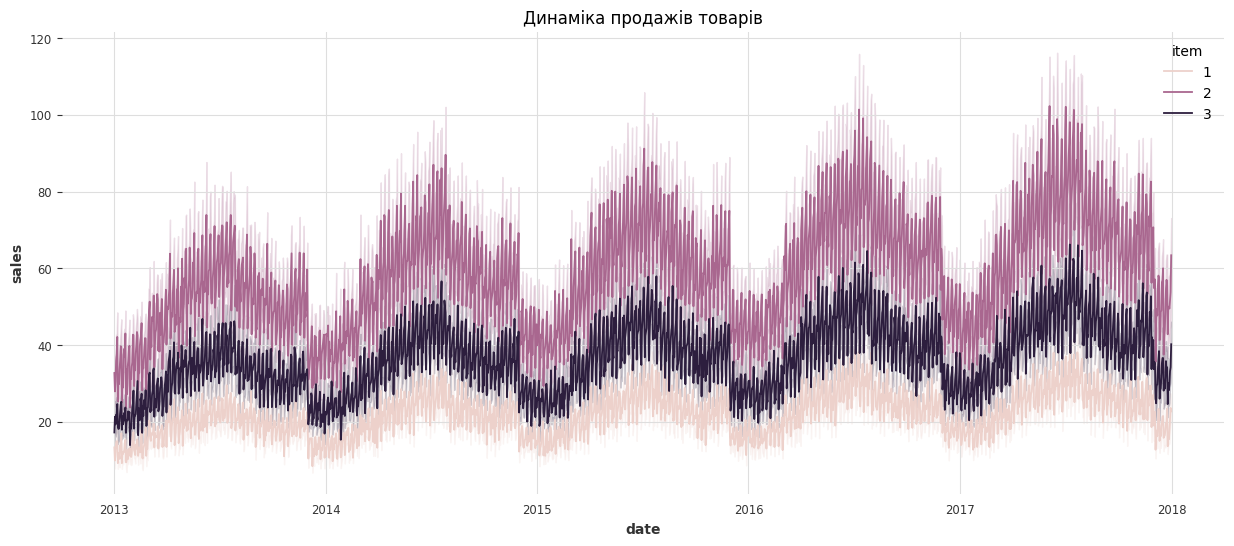

In [5]:
for_plt = raw_df[raw_df['item'].isin([1, 2, 3])]

plt.figure(figsize=(15, 6))
sns.lineplot(data=for_plt, x=for_plt.index, y='sales', hue='item')
plt.title('Динаміка продажів товарів')
plt.show()

Чіткий річний цикл літом більше, зимою менше та невеликий але стабільний ріст рік до року. Лінії різних товарів рухаються однаково. Це означає, що зовнішні фактори (свята, погода) впливають на всі товари однаково.

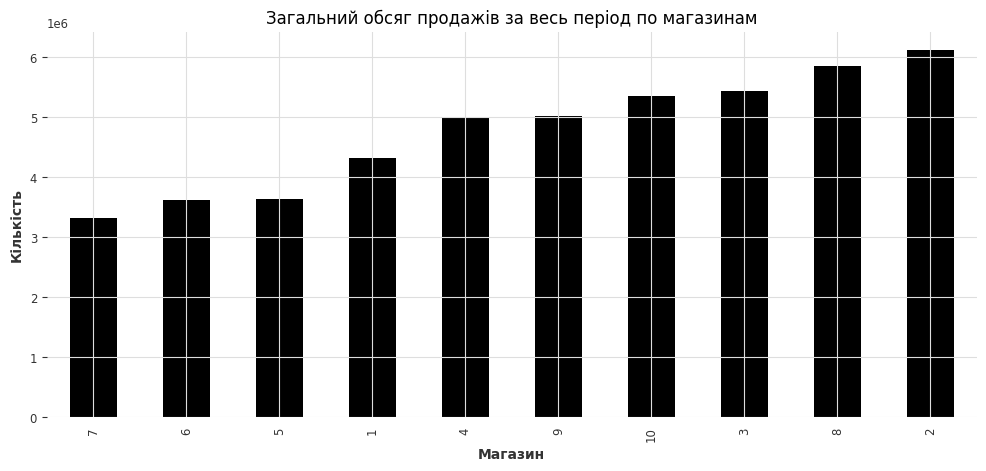

In [29]:
plt.figure(figsize=(12, 5))
raw_df.groupby('store')['sales'].sum().sort_values().plot(kind='bar')
plt.title('Загальний обсяг продажів за весь період по магазинам')
plt.ylabel('Кількість')
plt.xlabel('Магазин')
plt.show()

Продажі суттєво різняться залежно від магазину. Наприклад, Магазин №2 та №8 є лідерами, тоді як Магазин №7 продає майже вдвічі менше. Це свідчить про різну успішність торгових точок.

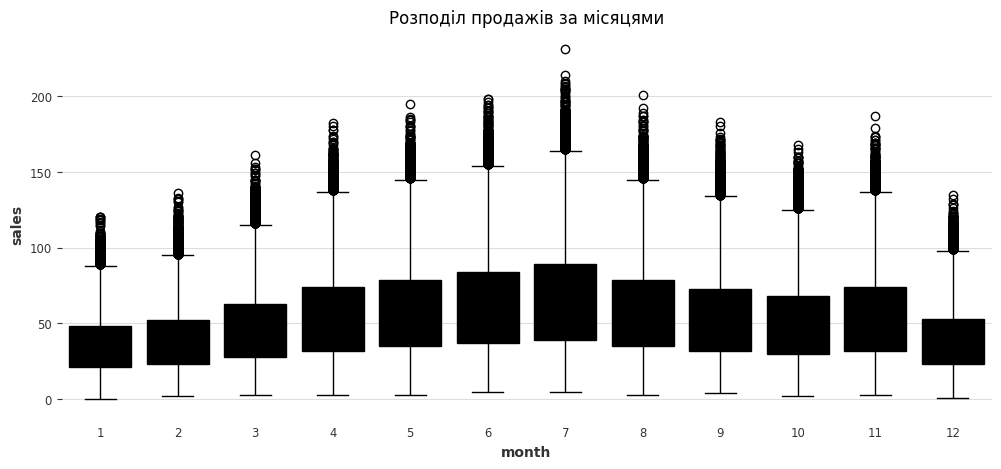

In [7]:
plt.figure(figsize=(12, 5))
raw_df['month'] = raw_df.index.month
sns.boxplot(data=raw_df, x='month', y='sales')
plt.title('Розподіл продажів за місяцями')
plt.show()

Графік підтверджує: травень-серпень — місяці з найвищими продажами. Наявність викидів показує, що іноді трапляються дні з аномально високим попитом, що може бути пов'язано з акціями або вихідними.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [8]:
single_series = raw_df[(raw_df['item'] == 1) & (raw_df['store'] == 1)].copy()

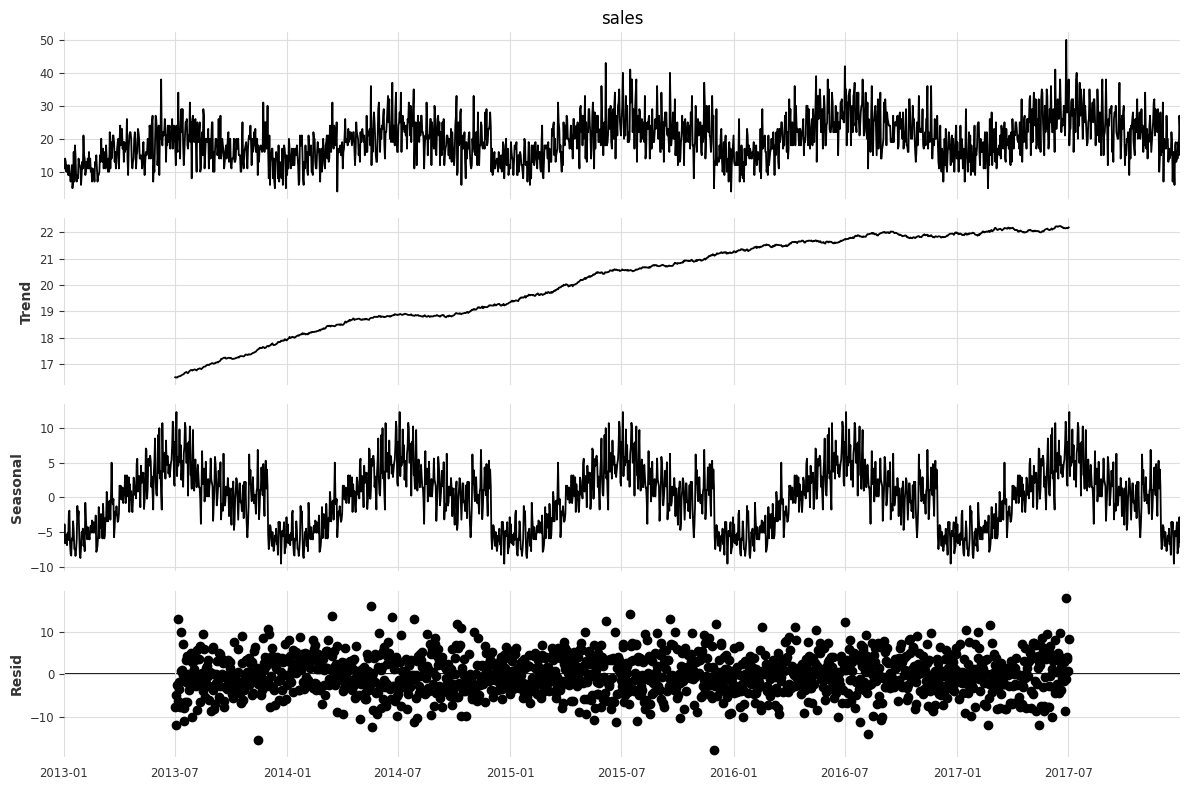

In [9]:
decompose = seasonal_decompose(single_series['sales'], model='additive', period=365)
plt.rc("figure", figsize=(12, 8))
decompose.plot()
plt.show()

Trend: Спостерігається чітка тенденція до зростання продажів з 2013 по 2017 рік. Продажі зросли приблизно з 16 до 22 одиниць на день. Це свідчить про те, що популярність товару або магазину збільшується.

Seasonal: Графік підтверджує наявність сильної річної сезонності. Продажі досягають піку в середині кожного року (літо) і падають до мінімуму взимку.

Resid: Залишки виглядають як випадковий шум, розподілений навколо нуля. Однак на графіку видно кілька поодиноких аномалій, які виходять за межі загальної маси — можливо це дні з високим або низьким попитом.

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [10]:
series = TimeSeries.from_dataframe(single_series, value_cols='sales', freq='D')

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

<Axes: xlabel='date'>

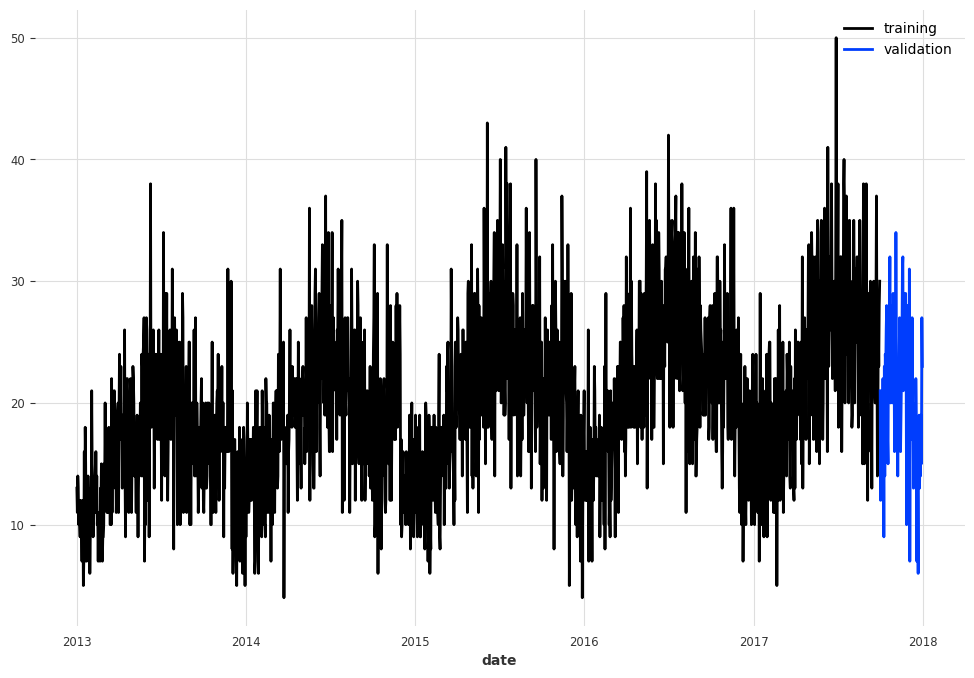

In [11]:
train, val = series.split_before(pd.Timestamp("2017-10-01"))
train.plot(label="training")
val.plot(label="validation")

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

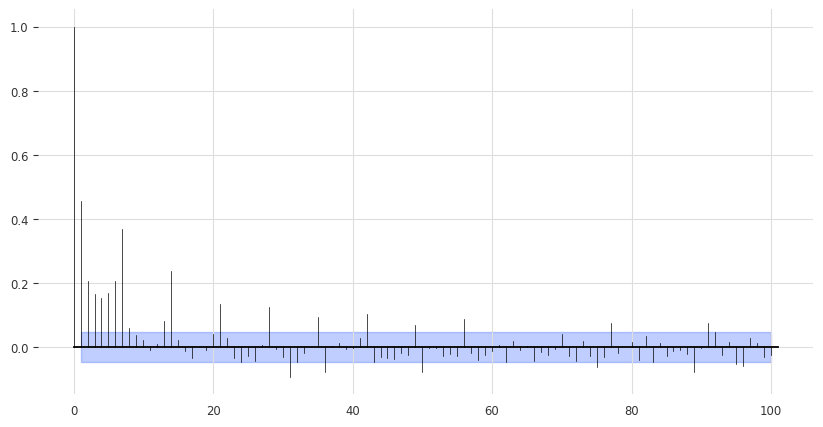

In [12]:
plot_pacf(train, alpha=0.05, max_lag=100)

Найвищу значущість мають лаги найближчих днів, обсяг продажів сьогодні визначається результатами попередніх 1-3 днів. Чіткий пік на 7-му лагу підтверджує пряму залежність продажів від аналогічного дня попереднього тижня. Більшість лагів після 30-го виходять за межі блакитної зони лише поодиноко, що вказує на те, що для прогнозу достатньо використовувати дані за останній місяць та сезонний компонент.

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [13]:
for m in range(2, 24):
    is_seasonal, period = check_seasonality(train, m=m, alpha=0.05)
    if is_seasonal:
        print("There is seasonality of order {}.".format(period))

There is seasonality of order 7.
There is seasonality of order 14.
There is seasonality of order 21.


8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

<Axes: xlabel='date'>

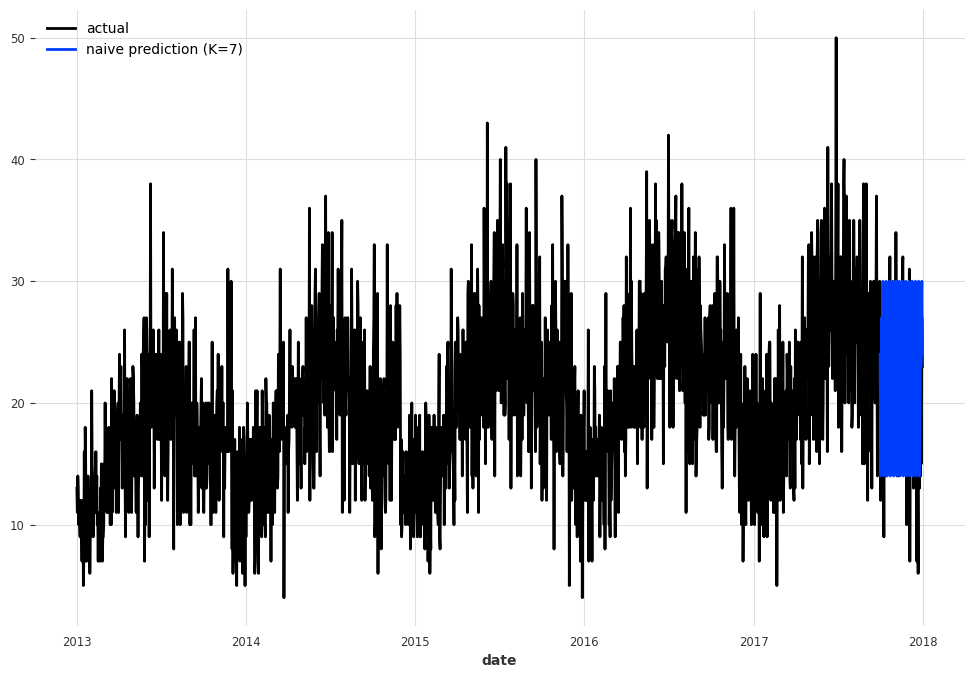

In [14]:
seasonal_model = NaiveSeasonal(K=7)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(n=len(val))

series.plot(label="actual")
seasonal_forecast.plot(label="naive prediction (K=7)")

<Axes: xlabel='date'>

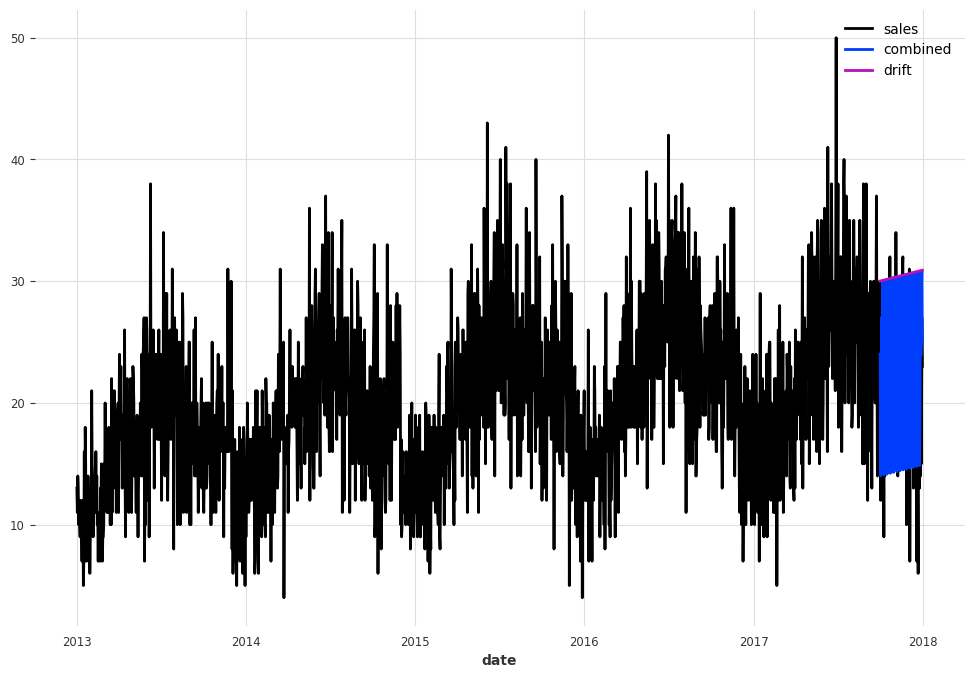

In [15]:
drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(n=len(val))

combined_forecast = drift_forecast + seasonal_forecast - train.last_value()

series.plot()
combined_forecast.plot(label="combined")
drift_forecast.plot(label="drift")


K=7 обрано на основі аналізу PACF та тесту check_seasonality. NaiveSeasonal копіює тільки тиждень. Вона не бачить річний цикл, який ми бачили на графіку. NaiveDrift це просто пряма лінія, грубий тренд. Реальний тренд може змінюватися, але ця модель цього не бачить. Модель копіює останні дні вересня, включно з випадковими сплесками або падіннями, які були в ті дні.

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [16]:
def eval_forecast(model, val, forecast):
  mape_ = mape(val, forecast)
  print(f"model {model} obtains MAPE: {mape_:.2f}%")
  return mape_

In [17]:
eval_forecast(drift_model, val, combined_forecast)

model NaiveDrift() obtains MAPE: 39.91%


39.90628951234137

10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [18]:
scaler = Scaler()
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)

In [19]:
xgb_model = XGBModel(
    lags=7,  
    output_chunk_length=1,  
    lags_future_covariates=[0],
    n_estimators=100,  
    max_depth=3,
    n_jobs=1,  
    learning_rate=0.1,
    subsample=0.8,  
    colsample_bytree=0.8, 
    add_encoders={
        'cyclic': {'future': ['month', 'dayofweek']}, 
        'datetime_attribute': {'future': ['year']} 
    }
)

xgb_model.fit(train_scaled)
pred_xgb_scaled = xgb_model.predict(n=len(val))
pred_original = scaler.inverse_transform(pred_xgb_scaled)

In [20]:
eval_forecast(xgb_model, val, pred_original)

model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=1, num_parallel_tree=None, ...) obtains MAPE: 22.22%


22.222173671369802

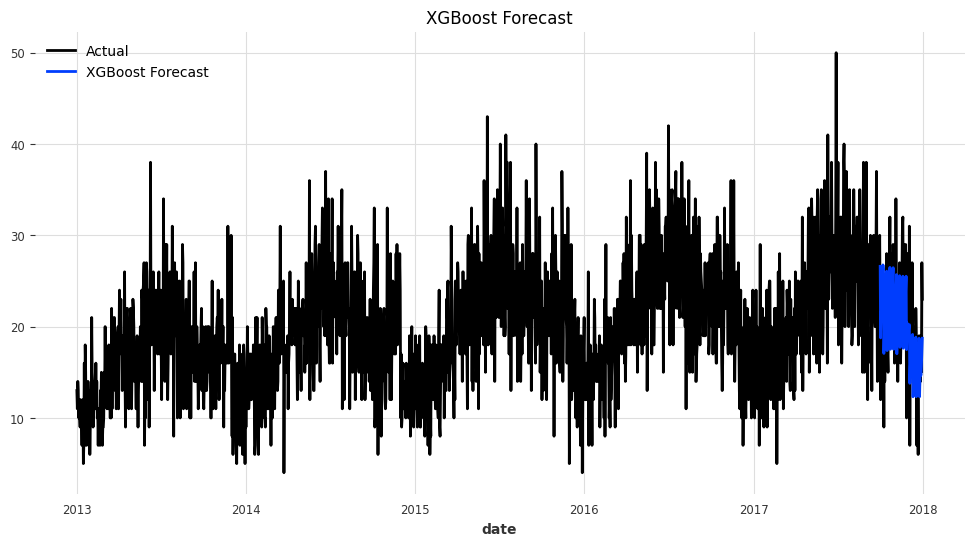

In [21]:
plt.figure(figsize=(12, 6))
series.plot(label="Actual")
pred_original.plot(label="XGBoost Forecast")
plt.title(f"XGBoost Forecast")
plt.legend()
plt.show()

Модель XGBoost значно краще впоралася з прогнозуванням, оскільки вона врахувала не лише лаги, а й календарні ознаки (місяць, день тижня). Помилка знизилася майже вдвічі порівняно з наївним прогнозом.

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

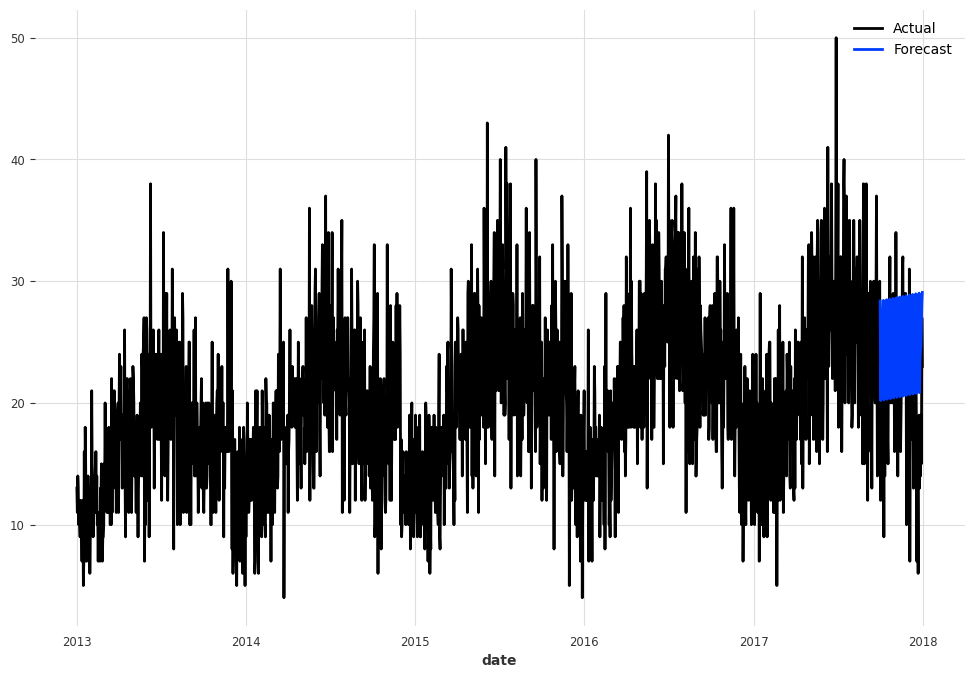

model ExponentialSmoothing(seasonal=ModelMode.ADDITIVE, seasonal_periods=7) obtains MAPE: 39.01%


In [22]:
def plot_results(series, forecast):
  # Візуалізація результатів
  series.plot(label='Actual')
  forecast.plot(label='Forecast')
  plt.legend()
  plt.show()

def fit_and_plot(model, series, train, val):
  model.fit(train)
  forecast = model.predict(len(val))
  plot_results(series, forecast)
  eval_forecast(model, val, forecast);

es_model = ExponentialSmoothing(
    seasonal_periods=7, 
    trend=ModelMode.ADDITIVE,  
    seasonal=ModelMode.ADDITIVE 
)
fit_and_plot(es_model, series, train, val)

Модель ExponentialSmoothing показала точність MAPE 39.01%, що лише на 0.9 % краще за наївний прогноз. Візуальний аналіз показує, що модель не встигаючи за різкими щоденними змінами попиту. У даному датасеті щоденні коливання настільки високиі, що модель сприймає сезонність як шум, що призводить до MAPE на рівні наївних моделей.

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

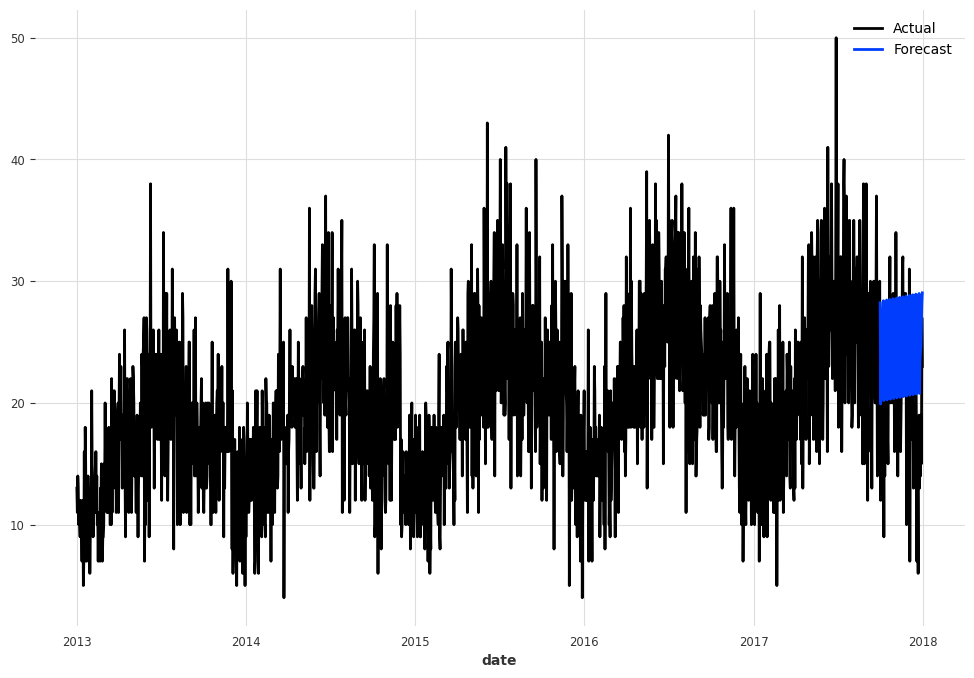

model ARIMA(p=1, q=1, seasonal_order=(1, 1, 1, 7)) obtains MAPE: 38.86%


In [23]:
arima_model = ARIMA(p=1, d=1, q=1, seasonal_order=(1, 1, 1, 7))

fit_and_plot(arima_model, series, train, val)

Модель ARIMA продемонструвала результат MAPE 38.86%. Візуальний аналіз показує, що прогноз швидко стабілізується до середнього значення, не в змозі відтворити реальні щоденні коливання. 

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

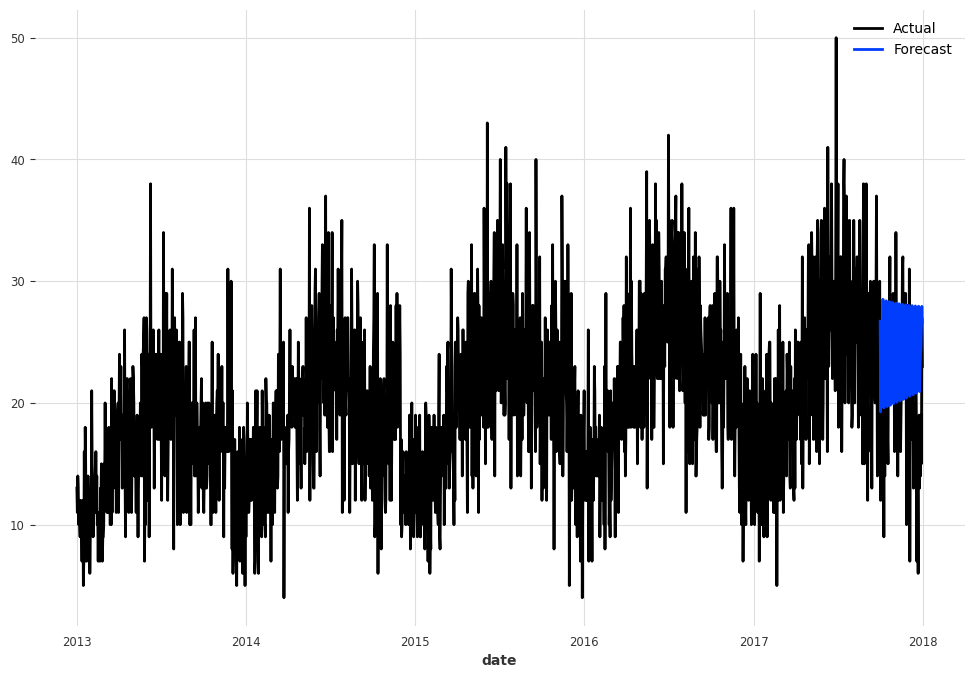

model AutoARIMA(start_p=1, max_p=7, start_q=1, max_q=3, seasonal=True, m=7) obtains MAPE: 37.82%


In [24]:
auto_arima_model = AutoARIMA(
    start_p=1, max_p=7, 
    start_q=1, max_q=3,
    seasonal=True, m=7)

fit_and_plot(auto_arima_model, series, train, val)

Незважаючи на врахування сезонності, графік прогнозу показує, що ARIMA-моделі схильні до прогнозування середнього значення з урахуванням циклічності, але вони не в змозі вловити різкі сплески.

14. Натренуйте модель Prophet та зробіть висновок про її якість.

00:54:18 - cmdstanpy - INFO - Chain [1] start processing
00:54:18 - cmdstanpy - INFO - Chain [1] done processing


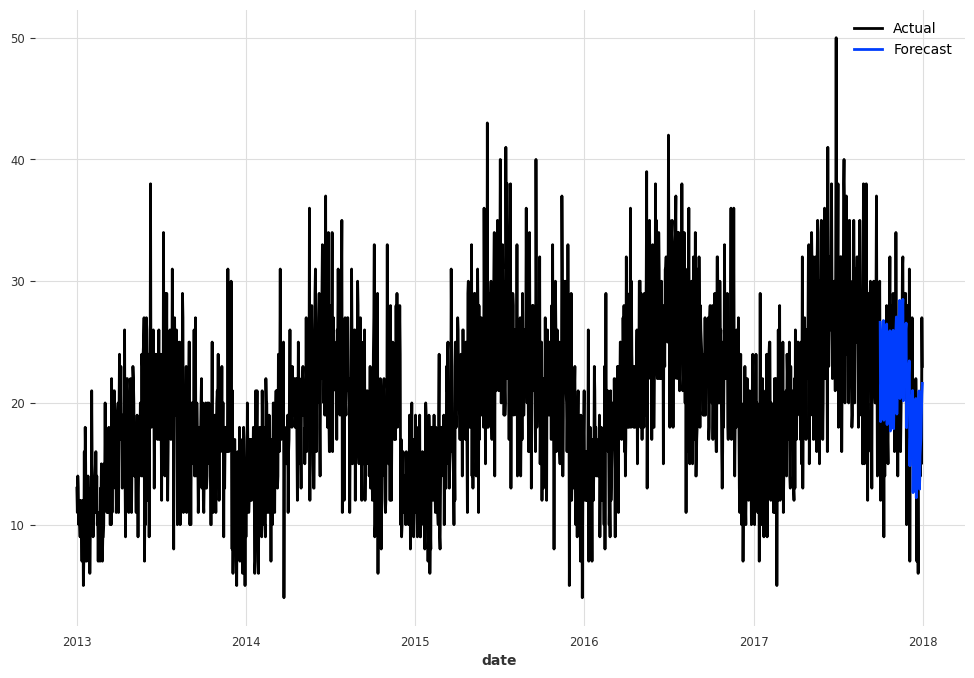

model Prophet() obtains MAPE: 23.78%


In [25]:
prophet_model = Prophet()
fit_and_plot(prophet_model, series, train, val)

Модель Prophet показала непогану точність 23.78%, що наблизило її до результатів градієнтного бустингу. Модель змогла ефективно відобразити складну динаміку ряду. Це робить Prophet однією з найсильніших моделей у даному дослідженні.

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/homebrew/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 3.4 K  | train
6 | V               | Linear           | 21     | train
-------------------------------------------------------------
3.4 K     Trainable params
0         Non-trainable params
3.4 K     Total params
0.014     Total estimated model params size (MB)
7         Module

Sanity Checking:   0%|          | 0/2 [00:00<?, ?it/s]

/opt/homebrew/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/homebrew/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 99: 100%|██████████| 86/86 [00:00<00:00, 280.77it/s, v_num=logs, train_loss=0.00652, val_loss=0.0118]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 86/86 [00:00<00:00, 280.31it/s, v_num=logs, train_loss=0.00652, val_loss=0.0118]


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 194.10it/s]


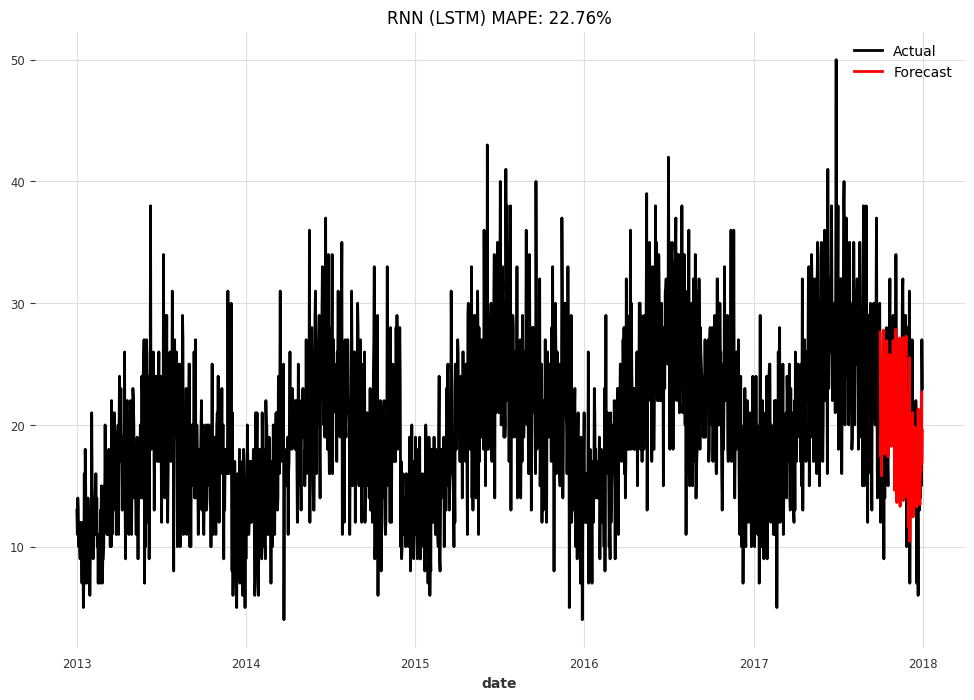

MAPE для LSTM: 22.76%


In [26]:
transformer = Scaler()
train_transformed = transformer.fit_transform(train)
val_transformed = transformer.transform(val)
series_transformed = transformer.transform(series)

covariates = datetime_attribute_timeseries(series, attribute="dayofweek", one_hot=True)
covariates = covariates.stack(datetime_attribute_timeseries(series, attribute="month", one_hot=True))

cov_transformer = Scaler()
covariates_transformed = cov_transformer.fit_transform(covariates)

my_rnn = RNNModel(
    model="LSTM",
    input_chunk_length=14,
    training_length=20, 
    hidden_dim=20,
    dropout=0,
    n_rnn_layers=1,
    batch_size=20,
    n_epochs=100,
    optimizer_kwargs={"lr": 1e-3},
    random_state=42,
    log_tensorboard=True,
    force_reset=True,
    pl_trainer_kwargs={
        "accelerator": "cpu"}
)

my_rnn.fit(
    train_transformed,
    future_covariates=covariates_transformed,
    val_series=val_transformed,
    val_future_covariates=covariates_transformed,
    verbose=True
)

forecast_transformed = my_rnn.predict(len(val))
forecast = transformer.inverse_transform(forecast_transformed)


series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.title(f"RNN (LSTM) MAPE: {mape(val, forecast):.2f}%")
plt.legend()
plt.show()

print(f"MAPE для LSTM: {mape(val, forecast):.2f}%")

Модель RNN (LSTM) продемонструвала високу точність із показником MAPE 22.76%. Модель ефективно врахувати як загальний тренд, так і складні сезонні коливання.

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

`enable_optimization=True` is ignored because `forecast_horizon > model.output_chunk_length`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.


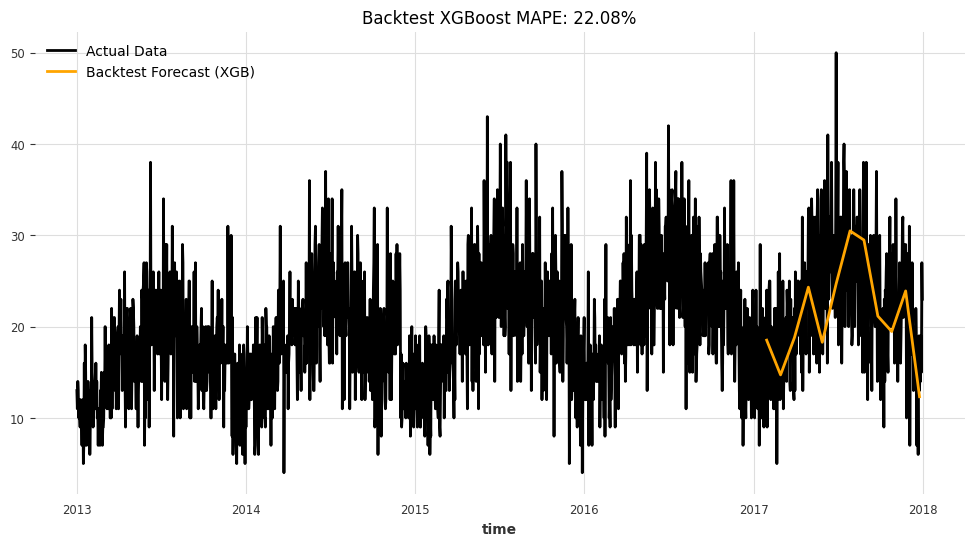

MAPE бектесту: 22.08%


In [27]:
historical_forecasts_scaled = xgb_model.historical_forecasts(
    series_transformed, 
    start=0.8,           
    forecast_horizon=30,
    stride=30,
    retrain=False,
    verbose=False
)

historical_forecasts = transformer.inverse_transform(historical_forecasts_scaled)

plt.figure(figsize=(12, 6))
series.plot(label='Actual Data', color='black')
historical_forecasts.plot(label='Backtest Forecast (XGB)', color='orange', lw=2)
plt.title(f"Backtest XGBoost MAPE: {mape(series, historical_forecasts):.2f}%")
plt.legend()
plt.show()

print(f"MAPE бектесту: {mape(series, historical_forecasts):.2f}%")

Модель поводиться стабільно. Як видно з графіка, лінія чітко повторює тренд та сезонні коливання реальних даних протягом усього 2017 року. Це означає, що модель не просто вгадала один відрізок, а реально вміє працювати з даними в динаміці.

Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

Я б узяв XGBoost. Вона працює як дуже розумна таблиця, яка вміє знаходити зв'язки. Я би тренував тільки одну модель. Навіть якщо в нас 50 товарів і 10 магазинів, нам не потрібно 500 різних «рограм. Ми вчимо одну модель XGBoost на всіх даних одразу. Вона просто отримує додаткову колонку «номер магазину» та «номер товару» і вчиться на всьому масиві. Вона бачить спільну картину, модель розуміє, що якщо у всіх магазинах по суботах продажі ростуть, то і в конкретному 10-му магазині буде так само. Не треба запускати 500 окремих клітинок у ноутбуці. Ти запускаєш одну, і вона видає прогноз для всіх точок. Також швидко, один раз навчити велику модель XGBoost швидше, ніж 500 разів чекати, поки порахується ARIMA чи LSTM.